# 🌳 Trees, Gini and more!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell.

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside this notebook.
- Answer the follow-up questions in markdown format within this notebook. A few sentences are enough; there is no length requirement.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Some questions and tasks are a bit vague. You are expected to apply techniques we learned in the lectures.
- Submit this notebook to Canvas. Deliver the notebook with its outputs saved; ideally, *restart* the kernel and then *run all*.

Good luck!

---

# 🌴 Problem 1: Fit a decision tree classifier!

### ❗️ The problem
In this first problem, you must load the data and train a decision tree classifier on the provided dataset!

### 📋 Formal requirements
1. **Implementation**:
   - Load `problem1.csv`
   - Analyse the dataset (e.g. the class distribution)
   - Preprocess the training data
   - Train a decision tree classifier
   - Implement the metrics presented in the lectures
2. **Performance**: Achieve at least **0.90** classification accuracy on the test set
3. **Discussion**:
   - What preprocessing do we need to apply before training, and why?
   - Do we need to scale the features?
   - What do you observe in the decision boundary plot before and after preprocessing?
   - What happens when you increase or decrease the depth of the tree?

In [732]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [733]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [734]:
# ====================================
# YOUR CODE GOES HERE: 
df = pd.read_csv("problem1.csv")
train = df[df["split"] == "train"]
test = df[df["split"] == "test"]
# ====================================


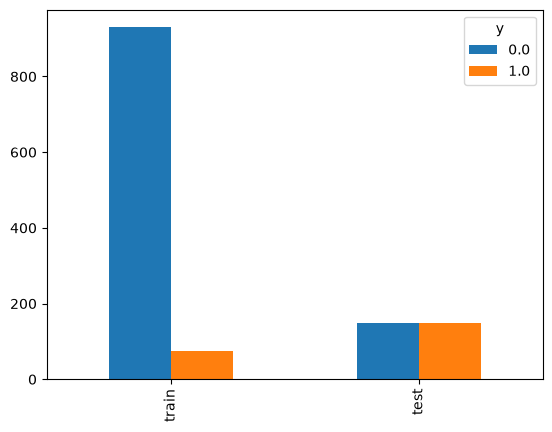

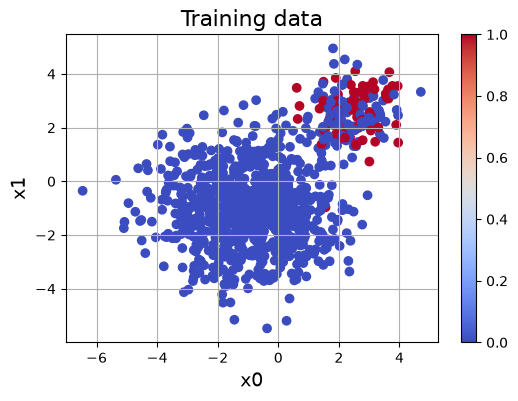

In [735]:
# ====================================
# YOUR CODE GOES HERE: let's analyse the dataset
pd.DataFrame({"train": train["y"].value_counts(), "test":test["y"].value_counts()}).T.plot(kind="bar") #Analyserer data via å visualisere fordelingene i test og treningsdataen 
# ====================================
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Training data', fontsize=16)
plt.colorbar()
plt.show()

In [736]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train = train[['x0', 'x1']]
y_train = train['y']
X_test = test[['x0', 'x1']]
y_test = test['y']

# ====================================
# YOUR CODE GOES HERE
# ====================================
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

#BEVIS PÅ OVERFITTING 
clf_on_tranined_data = DecisionTreeClassifier()
clf_on_tranined_data.fit(X_train, y_train)
y_pred_trained_date = clf_on_tranined_data.predict(X_train)
accuracy_on_trained_data = accuracy_score(y_train, y_pred_trained_date)
print(f"Accuracy for treningsdata: {accuracy_on_trained_data:.2f}")


# ====================================
print(f'Accuracy: {accuracy:.2f}')

Accuracy for treningsdata: 1.00
Accuracy: 0.68


### ❓ What preprocessing do we need to apply before training, and why?
(Kommentar: Vet ikke hvrorfor det blir gul tekst)
Slik som illustrert i tabellen over så har vi et ubalansert datasett. Testdataen er balansert med like mange punkter for 0 og 1, mens treningsdataen har en overepresentasjon av 0 i forhold til 1. 
Siden 0 er overepresentert og 1 er underepresentert har vi en prior probability shift da p(Ck), altså sannsynligheten for klassen 0, dominerer. I modeller med ubalansert data er ofte ROC AUC hly, mens andre metrikker er lave. Blant annet kan Recall være veldig lav siden positiv klasse er underepresentert.  
Det er hovedsakelig tre måter å håndtere ubalansert data på: Tilpasse klassifiseringsterskelen, resampling eller bruke vektet tapsfunksjon. 

    I resampling justerer vi dataen: 
        Undersampling: Trekker like mange datapunkter fra overrepresenterte klassen som det er tilgang på av den underrepresenterte. Like mange datapunkter, men potensielt få. Konsekvens -> underfitting
        Oversampling: Kopierer instanser fra den underrepresenterte slik at de er like mange datapunkter som den overrepresenterte. Konsekvens -> overfitting

    Når vi bruker vektet tapsfunksjonen kan vi straffe feil prediksjoner for klassen som er underrepresentert. For denne oppgaven velger jeg å utnytte sklearn sin class_weight parameter i DecisionTreeClassifier. Dette fungerer på samme måte som en vektet tapsfunksjon. Ved å tildele høyere vekt til den underrepresentere klassen og laverere vekt til den overepresenterte, tvinges modellen til å få mer fokus på minoriteten. Da ungår vi sykehustilfellet hvor modellen har høy accuracy fordi modellen belønnes for å predikere at alle datapunktene tilhører den overrepresenterte klassen. 

    Med class_weight = "Balanced" justeres vekten til hver klasse automatisk basert på frekvensen deres, noe, som nevnt tidligere, forbedrer modellen sin ytelse på de underrepresenterte klassene. 

I tillegg til ubalansert data må gjøre en preprocessing basert på accuracy for treningsdata og testdata. Forskjellen mellom Accuracy for treningsdata: 1.00 og Accuracy: 0.67 er såpass stor at det kan vise til at modellen er overfitted, noe som videre tydes på i decision boundary plot. Modellen har ikke generalisert mønsteret. 

### ❓ Do we need to scale the features?
Scaling er ikke nødvening i decisiontrees. Trærne deler data inn i regioner, så er ikke behov for å skalere den slik som vi bør gjøre i Regresjon. 

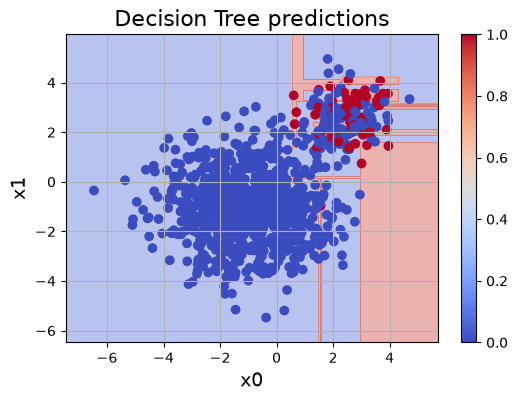

In [737]:
# visualize the decision boundary
x0_min, x0_max = train['x0'].min() - 1, train['x0'].max() + 1
x1_min, x1_max = train['x1'].min() - 1, train['x1'].max() + 1
xx0, xx1 = np.meshgrid(np.arange(x0_min, x0_max, 0.01),
                       np.arange(x1_min, x1_max, 0.01))

grid = pd.DataFrame({'x0': xx0.ravel(), 'x1': xx1.ravel()})
Z = clf.predict(grid)
Z = Z.reshape(xx0.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx0, xx1, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_train['x0'], X_train['x1'], c=y_train, cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Decision Tree predictions', fontsize=16)
plt.colorbar()
plt.show()

In [738]:
#NB! Lagde en ekstra kodeblokk da jeg var usikker hvor denne burde plasseres
clf = DecisionTreeClassifier(max_depth=3, class_weight="balanced")  
clf.fit(X_train, y_train)

print("Trening:", accuracy_score(y_train, clf.predict(X_train)))
print("Testing: ", accuracy_score(y_test,  clf.predict(X_test)))

y_pred = clf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Trening: 0.882703777335984
Testing:  0.91
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90       150
         1.0       0.86      0.99      0.92       150

    accuracy                           0.91       300
   macro avg       0.92      0.91      0.91       300
weighted avg       0.92      0.91      0.91       300



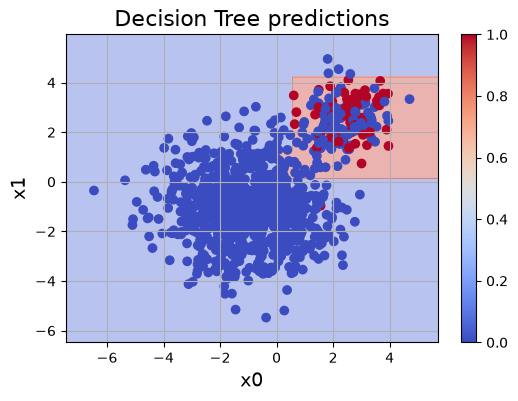

In [739]:
# visualize the decision boundary
x0_min, x0_max = train['x0'].min() - 1, train['x0'].max() + 1
x1_min, x1_max = train['x1'].min() - 1, train['x1'].max() + 1
xx0, xx1 = np.meshgrid(np.arange(x0_min, x0_max, 0.01),
                       np.arange(x1_min, x1_max, 0.01))

grid = pd.DataFrame({'x0': xx0.ravel(), 'x1': xx1.ravel()})
Z = clf.predict(grid)
Z = Z.reshape(xx0.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx0, xx1, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_train['x0'], X_train['x1'], c=y_train, cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Decision Tree predictions', fontsize=16)
plt.colorbar()
plt.show()

### ❓ What do you observe in the decision boundary plot before and after preprocessing?
Decision boundary: Området som separerer ulike klasser i et klassifiserings problem.

Før min preprocessing, så var modellen overfitted. Det kan ses med mengden røde og små rektangler. Det ser ut som at modellen predikerer hvert enkelt punkt med riktig klassifisering. Dette samsverer med accuracy dataen som sier Trenings accuracy: 1.00
Accuracy: 0.68. Istedenfor å da ha lært og generalisert mønsteret, har modellen istedenfor pugget treningssettet. Modellen er da overfitted. 

Ved å sette en maks dybde på treet og bruke class_weight = balanced, generaliserer modellen bedre. Dette reflekteres i accuracy Trening: 0.882703777335984 Testing:  0.91. Modellen pugger da ikke treningssettet og klarer da i større grad å predikere den underrepresenterte klassen. Videre viser den rosa blokken til en mye klarere generalisering fremfor at hvert røde punkt alltid predikeres riktig.  De aller fleste røde punktene er inni den røde boksen, og selv om det også er blå punkter her, utgjør de en liten del av mengden av blå punkter.  

### ❓ What happens when you increase or decrease the depth of the tree?
I beslutningstrær kan maks dybden på treet føre til underfitting eller overfitting. Om et tre er for grunnt, kan det hende at den ikke forstår de underliggende mønstrene og får da low variance og high bias. Noe som fører til dårlig acucracy på både trening og testing data. Om treet blir for dypt, kan modellen memorisere treningsdataen isetdenfor å generalisere. Dette kan fære til høy variance og lav bias med høy accuracy på treningssettet, men dårlig ytelse på test settet. 

Med en dypde på 3 får jeg: 
Train: 0.882703777335984
Test:  0.91

Om dypden bli mindre, feks = 2: 
Train: 0.9055666003976143
Test:  0.9033333333333333

Om dybden er større, feks =4: 
Train: 0.8986083499005965
Test:  0.8766666666666667

Test accuracy er da best med en dybde = 3. 

# 🌴🌴 Problem 2: Predict Viking voyage survivors 🗡️
### ❗️ The problem
You are given a dataset with information about the passengers on Viking voyages.
Your task is to develop a decision tree classifier that predicts which Vikings **survived** a **voyage**.

### 📋 Formal requirements
1. **Implementation**:
   - Do a simple data analysis
   - Preprocess the data 
   - Train a decision tree classifier
   - Report the cross-validation score and the test accuracy
   - Try different split criteria for the decision tree
   - Plot the decision tree
   - Use a boosting technique to improve the accuracy!
   - Use Naïve Bayes to predict whether a single new voyager survives
2. **Performance**: Achieve at least **0.80** classification accuracy on the test set
3. **Discussion**:
   - Analyse the dataset. Are there any features that already predict survival better than a random guess?
   - What is the purpose of cross-validation?
   - Which split criterion do you prefer, and why?
   - What is log_loss impurity? Use an example from the decision tree graph you created
   - Which terms of Bayes theorem can you estimate from this dataset, and which ones are difficult?
   - Use Naïve Bayes: does the new voyager have a higher or lower chance of surviving?

In [740]:

df = pd.read_csv('problem2.csv', keep_default_na=False, na_values=[""]) 
#print(df.head())


Let's start by understanding the dataset.


Female representation in voyage: 27.2%%
Male representation in voyage: 72.8%%

No duplicated rows
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   passenger_id   500 non-null    int64  
 1   name           500 non-null    str    
 2   sex            500 non-null    str    
 3   age            500 non-null    float64
 4   role           500 non-null    str    
 5   ship           500 non-null    str    
 6   destination    500 non-null    str    
 7   clan_origin    500 non-null    str    
 8   armor          500 non-null    str    
 9   provisions_kg  500 non-null    float64
 10  family_aboard  500 non-null    int64  
 11  prior_voyages  500 non-null    int64  
 12  survived       500 non-null    int64  
dtypes: float64(2), int64(4), str(7)
memory usage: 50.9 KB
passenger_id     0
name             0
sex              0
age              0
role        

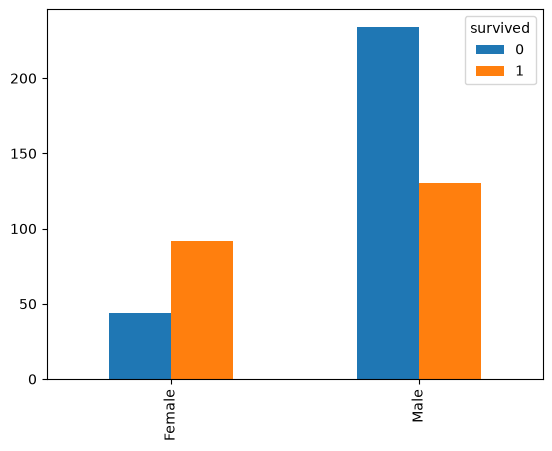

In [741]:
# Let's analyse the dataset
# Make some comments about what you print and what useful information it gives
# ====================================
# YOUR CODE GOES HERE: Let's analyse the dataset!
# ====================================
#Sex
female = df[df["sex"] == "Female"]
male = df[df["sex"] == "Male"]
survived_female = df[(df["sex"] == "Female") & (df["survived"]== 1)]
survived_male = df[(df["sex"] == "Male") & (df["survived"]== 1)]


# Visual representation
pd.DataFrame({"Female": female["survived"].value_counts(), "Male":male["survived"].value_counts()}).T.plot(kind="bar")

#Precentage representation 
female_representation = (len(female) / (len(female)+len(male)))
male_representation = (len(male) / (len(female)+len(male)))
print(f"\nFemale representation in voyage: {female_representation:.1%}%")
print(f"Male representation in voyage: {male_representation:.1%}%\n")

rate_female = len(survived_female) / len(female)
rate_male = len(survived_male) / len(male)

#General overiview of the data
#df.info() #Ser manglende verdier
#print(df.isnull().sum()) 

if (df.duplicated().sum() == 0):
    print("No duplicated rows")
else: 
    print(f"Duplicated rows:{df[df.duplicated()]}")

    
#Preprocessing: Mean av alder

df["age"] = df["age"].fillna(df["age"].mean())
df["armor"] = df["armor"].fillna("Unknown")
df["clan_origin"] = df["clan_origin"].fillna("Unknown")
df.info() #Ingen manglende verdier
print(df.isnull().sum())

#print(df.head()) #SJekker at Unkown er med

# ====================================
print(f"\nFemale survival rate: {rate_female:.1%}")
print(f"Male survival rate: {rate_male:.1%}")

### Kommentarer om hva jeg finner underveis i analysen:
* Selv om female survival rate er mye høyere enn male survival rate, så er ikke dette representativt nok for fungere som et bra splitting criteria da det er en mye større andel menn enn det det er kvinner. 
* Det er en del missing data tilstedet. 
  * 80 passasjerer har ingen age verdi 
  * 12 mangler en klan 
  * 324 rader har ikke armor informasjon 
  * Kan fjerne rader med manglende verdier med dropna(), da sitter jeg igjen med 141 passasjerer. Det å bare fjerne data gir ikke et godt grunnalg for analyse. 
  * For å håndtere missing values bruker jeg heller Dataframe.fillna() med mean(). Lager en kopi av dataen slik at jeg ikke redigerer orginal datan. 
    * Age er den eneste nummeriske verdien som har missing values. bruker da fillna() med mean() her. 
  * Armor har None som kategori for ingen beskyttelse, må da bruke keep_default_na=False når jeg leser dataen for at de skal bli behanldet som en faktisk kategori og ikke manglende data   
  * Fyller inn "unknown" på armor og clan orgion for de manglende verdiene.
* Ingen duplikat rader
* Antar at hverken navn eller id vil påvirke resultatet så fjerner disse.
* Siden det er en decsions tree trengs ikke scaling av features
* TODO: Usikker på om jeg skal droppe rader med mangelende verdier
* TODO: Skal jeg bruke laber encoder?

### ❓ Are there any features that already predict survival better than a random guess?
TODO

In [742]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
target = 'survived'
# ====================================
# YOUR CODE GOES HERE: Train the model:)
# ====================================
from sklearn.model_selection import train_test_split
df = df.drop(columns=["passenger_id", "name"])
category =["sex","role","ship","destination","clan_origin","armor",]
df = pd.get_dummies(df, columns=category)
print(df.head())

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) #hvorfor 42

#TRene modellen 
model = DecisionTreeClassifier(max_depth=4, random_state=42) #hvorfor 4
model.fit(X_train, y_train)

#testing av modellen 
pred = model.predict(X_test)
a = accuracy_score(y_test, pred)
cv_scores = cross_val_score(model, X_train, y_train)

print(classification_report(y_test, pred))

#print(export_text(model, feature_names=list(X.columns)))

# ====================================
print(f"Gini: CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Gini: Test accuracy: {a:.4f}")

    age  provisions_kg  family_aboard  prior_voyages  survived  sex_Female  \
0  25.0            2.0              3              0         0       False   
1  41.0            4.3              0              2         0       False   
2  29.0          132.2              1              3         1       False   
3  32.0            2.7              1              0         0        True   
4  26.0           35.7              3              2         0       False   

   sex_Male  role_Hirdman  role_Jarl  role_Karl  ...  destination_Vinland  \
0      True         False      False      False  ...                False   
1      True         False      False       True  ...                False   
2      True          True      False      False  ...                False   
3     False         False      False      False  ...                False   
4      True         False      False       True  ...                False   

   clan_origin_Borg  clan_origin_Kaupang  clan_origin_Nidaros  \
0  

### ❓ What is the purpose of cross validation? 
In cross validation, the data set is split into equally sized k-folds instead of into training and testing. This results in having k-models that test ion fold in each model, so it will end up looking sort of like kxk matrix of folds. The same fold will not be used for testing more than once and the other folds in the model will be used for training. The average score of the k models is used to get a more accurat evaluation. The goal of cross validation is to evaluate how well a model perform on unseen data while also preventing overfitting. 

In [743]:
# Compare the different split criteria TODO
# ====================================
# YOUR CODE GOES HERE: try the different split criteria (log_loss, entropy, log_loss)
# and report the cross-validation and test accuracy for each

#Gini er default verdien til DecisionTreeClassifier, så test accuracy og CV score for Gini splitting er i kodeboksen over. 

#ENTROPY 
entropy_model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42) #hvorfor 4
entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)
entropy_a = accuracy_score(y_test, entropy_pred)
entropy_cv_scores = cross_val_score(entropy_model, X_train, y_train)

print(classification_report(y_test, entropy_pred))


print(f"entropy: CV Accuracy: {entropy_cv_scores.mean():.3f} ± {entropy_cv_scores.std():.3f}")
print(f"entropy: Test accuracy: {entropy_a:.4f}")

#Loggloss 
log_loss_model = DecisionTreeClassifier(criterion='log_loss', max_depth=4, random_state=42) #hvorfor 4
log_loss_model.fit(X_train, y_train)

log_loss_pred =log_loss_model.predict(X_test)
log_loss_a = accuracy_score(y_test, log_loss_pred)
log_loss_cv_scores = cross_val_score(log_loss_model, X_train, y_train)

print(classification_report(y_test, log_loss_pred))


print(f"log_loss: CV Accuracy: {log_loss_cv_scores.mean():.3f} ± {log_loss_cv_scores.std():.3f}")
print(f"log_loss: Test accuracy: {log_loss_a:.4f}")
# ====================================


              precision    recall  f1-score   support

           0       0.70      0.82      0.75        56
           1       0.71      0.55      0.62        44

    accuracy                           0.70       100
   macro avg       0.70      0.68      0.68       100
weighted avg       0.70      0.70      0.69       100

entropy: CV Accuracy: 0.760 ± 0.031
entropy: Test accuracy: 0.7000
              precision    recall  f1-score   support

           0       0.70      0.82      0.75        56
           1       0.71      0.55      0.62        44

    accuracy                           0.70       100
   macro avg       0.70      0.68      0.68       100
weighted avg       0.70      0.70      0.69       100

log_loss: CV Accuracy: 0.760 ± 0.031
log_loss: Test accuracy: 0.7000


### ❓ Try different DecisionTreeClassifier criteria, report what accuracy you get. Which criterion do you prefer?

Gini: CV Accuracy: 0.755 ± 0.040
Gini: Test accuracy: 0.7700

entropy: CV Accuracy: 0.760 ± 0.031
entropy: Test accuracy: 0.7000

log_loss: CV Accuracy: 0.760 ± 0.031
log_loss: Test accuracy: 0.7000

Resultatet viser at entropy og log_loss gir identiske svar. 


Test accuracy er bedre hos Gini mens Cross validation accuracy er sterke hos entropy / log loss. 
Gini har best test accuracy (0.77 vs 0.7), mens entropy har bedre CV (0.76 vs 0.755). Likevel er forskjellene så små at det ikke gir et klart svar på om den ene er bedre enn den andre. 
Gini er standardalternativet og er raskere å benytte seg av da den ikke inneholder logaritmer. Siden det er så små forskjeller mellom dem begge, foretrekker jeg derfor Gini. 

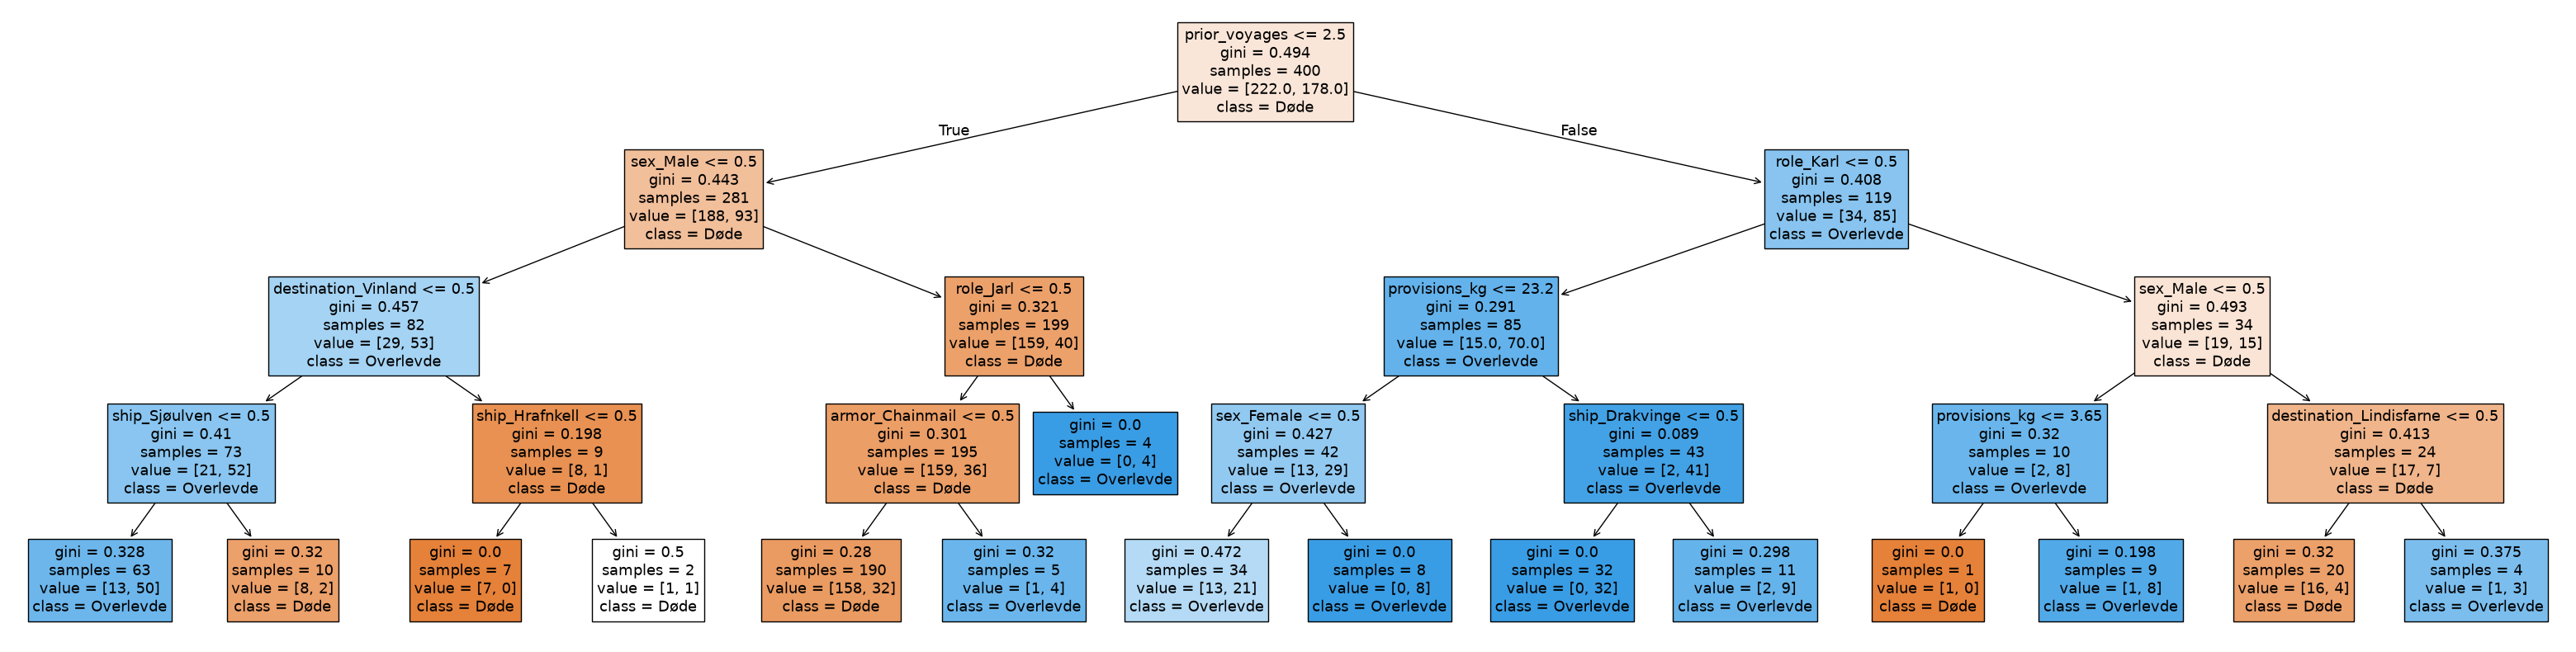

In [744]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# ====================================
# YOUR CODE GOES HERE: Plot the decision tree nodes! 

#VISUALISERING Her loker jeg rundt 
#TODO Fjern før innlevering 
#TODO skal jeg faktisk skalere / preprocesse?
#TODO spør om hvorfor teksten blir rar 
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40, 10))

plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=["Døde", "Overlevde"],
    filled=True,
    fontsize=13,
)

plt.show()
# ====================================


### ❓ What is Gini? Use an example from the decision tree graph you created.
Gini er et splitting kriterium som angir hvor sannsynlig det er for at et nytt tilfeldig punkt feilklassifiseres om den får en tilfeldig “label” i henhold til klasse distribusjonen i data settet. Om Gini urenheten er høy betyr det at klassene er forholdsvis likt representert, mens en lav gini urenhet viser til at de fleste punktene tilhører den samme klassen. 
Feks løvnoden tredje fra venstre er Gini 0.0. Dette betyr at noden er helt "pure" / ren. Jo mørkere fargen er i løvnodene, jo renere er de. Feks den hvite løvnoden viser til at maks urenhet, det er 50/50 hvilken klasse den tilhører.
Treet viser at prior_voyages er det beste å splitte på. Om man har 2 eller færre tidligere turer, er det kjønn den neste kategorien som avgjør overlevese. Hos de erfarne er det rollen osv. 

## Improving the results with boosting 🚀

In [745]:
from sklearn.ensemble import AdaBoostClassifier
# ====================================
# YOUR CODE GOES HERE: Use AdaBoostClassifier to get even better results! TODO
# ====================================

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42,
)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
ada_cv_scores = cross_val_score(ada_model, X_train, y_train)
# ====================================
ada_acc = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost CV Accuracy: {ada_cv_scores.mean():.3f} ± {ada_cv_scores.std():.3f}")
print(f"AdaBoost test accuracy: {ada_acc:.4f}")

AdaBoost CV Accuracy: 0.818 ± 0.040
AdaBoost test accuracy: 0.7800


### ❓ Try estimating the factors of Bayes theorem using this dataset. What terms can you estimate and which ones are difficult and why?
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Lett å estimere: 
* P(A), P(B) og P(B|A) om det er enkeltegenskaper. Om B er kontinuerlig eller flere egenskaper, kan det bli vanskelig og da må vi kanskje forenklende antagelser slik som i Naive Bayes

Vanskelig å estimere: 
* Mange egenskaper samtidig. Da får vi kjenne på dimensjonalitets forbannelse siden det er 500 rader og mange kategorier med flere ulike kombinasjoner. 
* Kontinuerlige variabler: Får å bruke kontinuerlige variabler må de deles inn i intervaller eller få en annen fordeling. 

In [746]:
# ====================================
# YOUR CODE GOES HERE: estimate the terms of Bayes theorem you can TODO
# ====================================
A = df["survived"] == 1 #Viktinger som overlevde

#Estimerer overlevelse basert på om vikingen er en mann 
B = df["sex_Male"] == 1 #Menn som overlevde

PA = A.mean()
PB = B.mean()
PB_given_A = (A&B).sum() / A.sum()
PA_given_B = (A&B).sum () / B.sum()
Bayes_PA_given_B = (PA_given_B * PA)/PB
print(f"Bayes teorem P('survived' | 'male') = {Bayes_PA_given_B:.3f}")






Bayes teorem P('survived' | 'male') = 0.218


### ❓ Use Naïve Bayes. Does Endre have a higher or lower chance of surviving than dying on a voyage?

A voyager named **Endre** is about to set sail. This is what we know about him:

| Feature | Value |
| --- | --- |
| `sex` | Male |
| `age` | 25 |
| `role` | Hirdman |
| `ship` | Drakvinge |
| `destination` | Normandy |
| `clan_origin` | Nidaros |
| `armor` | Chainmail |
| `provisions_kg` | 49 |
| `family_aboard` | 2 |
| `prior_voyages` | 12 |

Does he have a **higher or lower** chance of surviving the voyage?

In [747]:
# ====================================
# YOUR CODE GOES HERE: Naïve Bayes
# You can either do this by hand or with code. TODO
# Do not import libraries.
# ====================================
